# Automobile Dataset: Structured Exploratory Data Analysis

This notebook performs a **read-only inspection** of the raw automobile dataset. It is intentionally organized as a sequence: understand the file first, inspect data quality second, and visualize distributions and relationships last.

## Questions this notebook answers

1. Can the source file be located and loaded correctly?
2. How many rows and columns are present?
3. Which columns are numeric, categorical, or date-like?
4. Where are values missing?
5. Are any rows duplicated?
6. What unique values and category inconsistencies exist?
7. How are numeric and categorical values distributed?
8. Which numeric variables are related?

> No cleaning or transformation is applied here. The raw dataframe is preserved for the future ETL notebook or pipeline.

## 1. Setup

Use the project's `.venv` kernel, then import the required libraries and apply consistent display and chart settings.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.dpi": 110,
})

PRIMARY_COLOR = "#2563EB"
SECONDARY_COLOR = "#F59E0B"
print("Setup complete.")

Setup complete.


## 2. Locate and load the raw dataset

The path check supports running Jupyter from either the project root or the `notebooks` directory. `df_raw` is the untouched source dataframe; `df` is a working copy used only for inspection.

In [2]:
DATA_FILE = Path("data/raw/automobileEDA_dirty_training.csv")
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / DATA_FILE).exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / DATA_FILE
assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH.resolve()}"

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy(deep=True)

print(f"Loaded: {DATA_PATH.resolve()}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Loaded: C:\Users\rbby-work\software-engineer-project\rework-academy-ai-engineer\assignment-data-pipeline-muhammad-rabby-ilyas\data\raw\automobileEDA_dirty_training.csv
Rows: 205
Columns: 30


## 3. First look at the records

Start with the first and last records. This helps reveal formatting differences without changing the data.

In [3]:
display(df.head())
display(df.tail())

,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,2025-01-01,3,122,alfa-romero,std,two,convertible,rwd,front,88.600,0.811,0.890,48.800,2548,dohc,four,130,mpfi,3.470,2.680,9.000,111.000,"5,000.000",21,27,"13,495.000",11.190,Medium,0,1
1,02/01/2025,3,122,alfa-romero,std,two,convertible,rwd,front,88.600,0.811,0.890,48.800,2548,dohc,four,130,mpfi,3.470,2.680,9.000,111.000,"5,000.000",21,27,"16,500.000",11.190,Medium,0,1
2,01-03-2025,1,122,ALFA-ROMERO,std,two,hatchback,rwd,front,94.500,0.823,0.910,52.400,2823,ohcv,six,152,mpfi,2.680,3.470,9.000,154.000,"5,000.000",19,26,"16,500.000",12.368,Medium,0,1
3,04-Jan-2025,2,164,audi,std,four,sedan,fwd,front,99.800,0.849,0.919,54.300,2337,ohc,four,109,mpfi,3.190,3.400,10.000,102.000,"5,500.000",24,30,"13,950.000",9.792,Medium,0,1
4,2025-01-05,2,164,audi,std,four,sedan,4wd,front,99.400,0.849,0.922,54.300,2824,ohc,five,136,mpfi,3.190,3.400,8.000,115.000,"5,500.000",18,22,"17,450.000",13.056,Medium,0,1


,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
200,2025-07-20,-1,95,volvo,turbo,four,sedan,rwd,front,109.100,0.907,0.957,55.500,3062,ohc,four,141,mpfi,3.780,3.150,9.500,114.000,"5,400.000",19,25,"22,625.000",12.368,Medium,0,1
201,06/01/2025,2,122,audi,std,two,sedan,fwd,front,99.800,0.852,0.921,53.100,2507,ohc,five,136,mpfi,3.190,3.400,8.500,110.000,"5,500.000",19,25,"15,250.000",12.368,Medium,0,1
202,26/01/2025,1,148,dodge,std,four,sedan,fwd,front,93.700,0.756,0.886,50.600,1989,ohc,four,90,2bbl,2.970,3.230,9.400,68.000,"5,500.000",31,38,"7,609.000",7.581,Low,0,1
203,2025-03-02,0,122,mazda,std,four,sedan,fwd,front,98.800,0.854,0.924,55.500,2443,ohc,four,122,idi,3.390,3.390,22.700,64.000,"4,650.000",36,42,"10,795.000",6.528,Low,1,0
204,2025-04-11,0,108,NaN,std,four,sedan,fwd,front,100.400,0.887,0.924,55.100,3060,ohcv,six,181,mpfi,3.430,3.270,9.000,152.000,"5,200.000",19,25,"13,499.000",12.368,Medium,0,1


A reproducible random sample gives another view of the dataset and can expose issues that are not visible at the beginning or end.

In [4]:
display(df.sample(n=min(5, len(df)), random_state=42))

,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
15,16-Jan-2025,0,122,bmw,std,NaN,sedan,rwd,front,103.500,0.931,0.943,53.700,3380,ohc,six,209,mpfi,3.620,3.390,8.000,182.000,"5,400.000",16,22,"41,315.000",14.688,High,0,1
9,10/01/2025,2,192,bmw,std,two,sedan,rwd,front,101.200,0.850,0.900,54.300,2395,ohc,four,108,mpfi,3.500,2.800,8.800,101.000,"5,800.000",23,29,"16,430.000",10.217,Low,0,1
100,2025-04-11,0,108,NaN,std,four,sedan,fwd,front,100.400,0.887,0.924,55.100,3060,ohcv,six,181,mpfi,3.430,3.270,9.000,152.000,"5,200.000",19,25,"13,499.000",12.368,Medium,0,1
132,2025-05-13,3,150,saab,turbo,two,hatchback,fwd,front,99.100,0.897,0.924,56.100,2808,dohc,four,121,mpfi,3.540,3.070,9.000,160.000,"5,500.000",19,26,"18,150.000",12.368,High,0,1
68,2025-03-10,-1,122,mercedes-benz,std,four,sedan,rwd,front,115.600,0.974,0.996,56.500,3740,ohcv,eight,234,mpfi,3.460,3.100,8.300,155.000,"4,750.000",16,18,"34,184.000",14.688,Medium,0,1


## 4. Inspect the structure and data types

First inspect pandas' inferred types, then build a compact profile for every column.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_date   203 non-null    str    
 1   symboling          205 non-null    int64  
 2   normalized-losses  205 non-null    int64  
 3   make               203 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       203 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

In [6]:
column_profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100),
    "unique_non_null": df.nunique(dropna=True),
})

display(column_profile)

,dtype,non_null,missing,missing_pct,unique_non_null
transaction_date,str,203,2,0.976,199
symboling,int64,205,0,0.000,6
normalized-losses,int64,205,0,0.000,51
make,str,203,2,0.976,27
aspiration,str,205,0,0.000,2
num-of-doors,str,203,2,0.976,2
body-style,str,205,0,0.000,7
drive-wheels,str,205,0,0.000,5
engine-location,str,205,0,0.000,2
wheel-base,float64,205,0,0.000,52


## 5. Check missing values

The summary is sorted so the columns needing the most attention appear first. The graph makes the relative size of each issue easy to compare.

In [7]:
missing_summary = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": df.isna().mean().mul(100),
    })
    .query("missing_count > 0")
    .sort_values(["missing_count", "missing_pct"], ascending=False)
)

print(f"Total missing cells: {int(df.isna().sum().sum()):,}")
display(missing_summary)

Total missing cells: 17


,missing_count,missing_pct
stroke,4,1.951
horsepower,3,1.463
price,3,1.463
transaction_date,2,0.976
make,2,0.976
num-of-doors,2,0.976
horsepower-binned,1,0.488


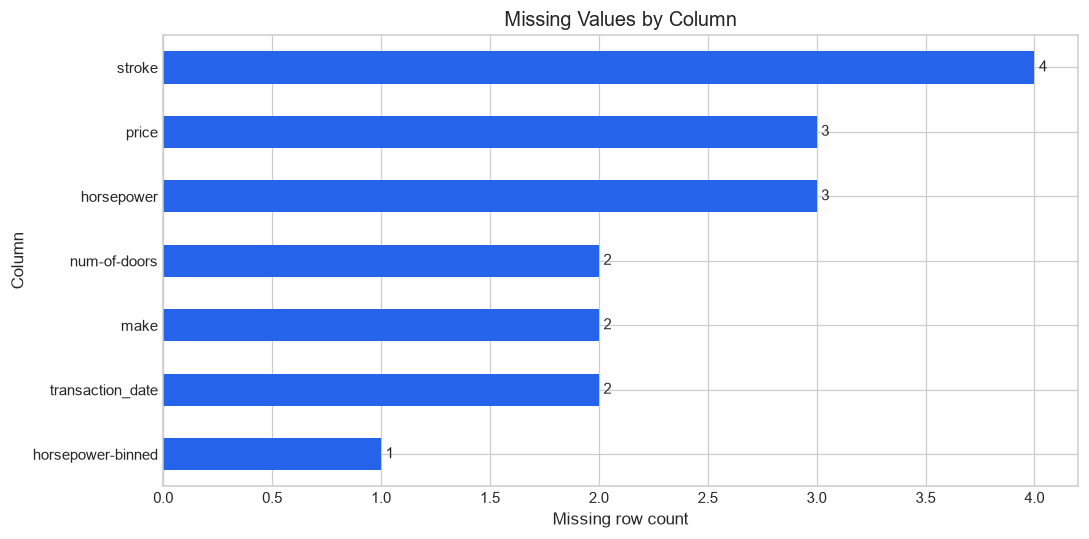

In [8]:
if missing_summary.empty:
    print("No missing values found.")
else:
    ax = missing_summary["missing_count"].sort_values().plot(
        kind="barh", color=PRIMARY_COLOR
    )
    ax.set_title("Missing Values by Column")
    ax.set_xlabel("Missing row count")
    ax.set_ylabel("Column")
    for container in ax.containers:
        ax.bar_label(container, padding=3)
    plt.tight_layout()
    plt.show()

## 6. Check duplicate rows

Show all members of duplicate groups, not only the later copies. This makes each repeated record easy to compare with its original.

In [9]:
duplicate_mask = df.duplicated(keep=False)
duplicate_copy_count = int(df.duplicated().sum())

print(f"Duplicate copies to remove: {duplicate_copy_count:,}")
print(f"Rows participating in duplicate groups: {int(duplicate_mask.sum()):,}")

if duplicate_mask.any():
    display(df.loc[duplicate_mask].sort_values(list(df.columns)).reset_index())
else:
    print("No exact duplicate rows found.")

Duplicate copies to remove: 4
Rows participating in duplicate groups: 8


,index,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,5,06/01/2025,2,122,audi,std,two,sedan,fwd,front,99.800,0.852,0.921,53.100,2507,ohc,five,136,mpfi,3.190,3.400,8.500,110.000,"5,500.000",19,25,"15,250.000",12.368,Medium,0,1
1,201,06/01/2025,2,122,audi,std,two,sedan,fwd,front,99.800,0.852,0.921,53.100,2507,ohc,five,136,mpfi,3.190,3.400,8.500,110.000,"5,500.000",19,25,"15,250.000",12.368,Medium,0,1
2,60,2025-03-02,0,122,mazda,std,four,sedan,fwd,front,98.800,0.854,0.924,55.500,2443,ohc,four,122,idi,3.390,3.390,22.700,64.000,"4,650.000",36,42,"10,795.000",6.528,Low,1,0
3,203,2025-03-02,0,122,mazda,std,four,sedan,fwd,front,98.800,0.854,0.924,55.500,2443,ohc,four,122,idi,3.390,3.390,22.700,64.000,"4,650.000",36,42,"10,795.000",6.528,Low,1,0
4,100,2025-04-11,0,108,NaN,std,four,sedan,fwd,front,100.400,0.887,0.924,55.100,3060,ohcv,six,181,mpfi,3.430,3.270,9.000,152.000,"5,200.000",19,25,"13,499.000",12.368,Medium,0,1
5,204,2025-04-11,0,108,NaN,std,four,sedan,fwd,front,100.400,0.887,0.924,55.100,3060,ohcv,six,181,mpfi,3.430,3.270,9.000,152.000,"5,200.000",19,25,"13,499.000",12.368,Medium,0,1
6,25,26/01/2025,1,148,dodge,std,four,sedan,fwd,front,93.700,0.756,0.886,50.600,1989,ohc,four,90,2bbl,2.970,3.230,9.400,68.000,"5,500.000",31,38,"7,609.000",7.581,Low,0,1
7,202,26/01/2025,1,148,dodge,std,four,sedan,fwd,front,93.700,0.756,0.886,50.600,1989,ohc,four,90,2bbl,2.970,3.230,9.400,68.000,"5,500.000",31,38,"7,609.000",7.581,Low,0,1


## 7. Check unique values

Unique-value counts reveal identifiers, low-cardinality numeric fields, and categorical fields that may need normalization.

In [10]:
unique_summary = (
    pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "unique_including_missing": df.nunique(dropna=False),
        "unique_non_null": df.nunique(dropna=True),
    })
    .sort_values("unique_including_missing")
)
display(unique_summary)

,dtype,unique_including_missing,unique_non_null
aspiration,str,2,2
engine-location,str,2,2
gas,int64,2,2
diesel,int64,2,2
num-of-doors,str,3,2
horsepower-binned,str,4,3
drive-wheels,str,5,5
engine-type,str,6,6
symboling,int64,6,6
body-style,str,7,7


### 7.1 Categorical unique values and frequencies

Print every value for manageable columns. For high-cardinality columns, show only the 20 most frequent values to keep the notebook readable.

In [11]:
categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()

for column in categorical_columns:
    counts = df[column].value_counts(dropna=False)
    print("\n" + "=" * 80)
    print(f"{column}: {df[column].nunique(dropna=True)} unique non-null values")
    if len(counts) <= 30:
        display(counts.rename("count").to_frame())
    else:
        print("High-cardinality column — showing the 20 most frequent values.")
        display(counts.head(20).rename("count").to_frame())


transaction_date: 199 unique non-null values
High-cardinality column — showing the 20 most frequent values.


C:\Users\rbby-work\AppData\Local\Temp\ipykernel_8544\229343926.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()


,count
transaction_date,
06/01/2025,2
26/01/2025,2
NaN,2
2025-03-02,2
2025-04-11,2
2025-01-01,1
02/01/2025,1
01-03-2025,1
04-Jan-2025,1



make: 27 unique non-null values


,count
make,
toyota,33
mazda,18
nissan,17
honda,12
mitsubishi,12
subaru,12
volkswagen,12
volvo,11
peugot,10


...

,count
num-of-cylinders,
four,159
six,25
five,11
two,4
eight,4
three,1
twelve,1



fuel-system: 10 unique non-null values


,count
fuel-system,
mpfi,94
2bbl,64
idi,20
1bbl,11
spdi,9
4bbl,3
MPFI,1
mfi,1
spfi,1



horsepower-binned: 3 unique non-null values


,count
horsepower-binned,
Low,117
Medium,64
High,23
NaN,1


### 7.2 Low-cardinality numeric values

Numeric columns with few possible values may actually represent categories, flags, or ratings.

In [12]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()
low_cardinality_numeric = [
    column for column in numeric_columns if df[column].nunique(dropna=True) <= 10
]

for column in low_cardinality_numeric:
    print(f"\n{column}")
    display(
        df[column]
        .value_counts(dropna=False)
        .sort_index()
        .rename("count")
        .to_frame()
    )


symboling


,count
symboling,
-2,3
-1,22
0,67
1,53
2,33
3,27



diesel


,count
diesel,
0,184
1,21



gas


,count
gas,
0,21
1,184


## 8. Check categorical consistency

Compare raw category counts with values normalized only in temporary series using trimmed lowercase text. A reduction indicates capitalization or whitespace inconsistencies.

In [13]:
consistency_rows = []

for column in categorical_columns:
    raw_values = df[column].dropna().astype(str)
    normalized_values = raw_values.str.strip().str.lower()
    raw_unique = raw_values.nunique()
    normalized_unique = normalized_values.nunique()
    consistency_rows.append({
        "column": column,
        "raw_unique": raw_unique,
        "normalized_unique": normalized_unique,
        "possible_inconsistent_labels": raw_unique - normalized_unique,
    })

consistency_summary = (
    pd.DataFrame(consistency_rows)
    .sort_values("possible_inconsistent_labels", ascending=False)
)
display(consistency_summary)

,column,raw_unique,normalized_unique,possible_inconsistent_labels
1,make,27,22,5
9,fuel-system,10,8,2
4,body-style,7,5,2
5,drive-wheels,5,4,1
0,transaction_date,199,199,0
2,aspiration,2,2,0
3,num-of-doors,2,2,0
6,engine-location,2,2,0
7,engine-type,6,6,0
8,num-of-cylinders,7,7,0


In [14]:
for column in categorical_columns:
    values = df[column].dropna().astype(str)
    groups = {}
    for raw_value in values.unique():
        normalized_value = raw_value.strip().lower()
        groups.setdefault(normalized_value, []).append(raw_value)

    inconsistent_groups = {
        normalized: variants
        for normalized, variants in groups.items()
        if len(variants) > 1 or any(value != value.strip() for value in variants)
    }

    if inconsistent_groups:
        print(f"\n{column}")
        for normalized, variants in inconsistent_groups.items():
            print(f"  {variants} -> {normalized!r}")


make
  ['alfa-romero', 'ALFA-ROMERO'] -> 'alfa-romero'
  ['audi', 'Audi'] -> 'audi'
  ['bmw', 'BMW'] -> 'bmw'
  ['dodge', 'dodge  '] -> 'dodge'
  ['mercury  '] -> 'mercury'
  ['porsche', 'porsche  '] -> 'porsche'

body-style
  ['sedan', 'SEDAN', 'Sedan'] -> 'sedan'

drive-wheels
  ['rwd', 'RWD'] -> 'rwd'

fuel-system
  ['mpfi', 'MPFI', 'Mpfi'] -> 'mpfi'


## 9. Inspect the transaction date formats

Identify each format before parsing. This avoids silently interpreting ambiguous dates with the wrong day/month order. Parsed dates are stored in a separate series; the source column is unchanged.

,row_count
transaction_date,
DD/MM/YYYY,52
YYYY-MM-DD,51
MM-DD-YYYY,50
DD-Mon-YYYY,50
Missing,2


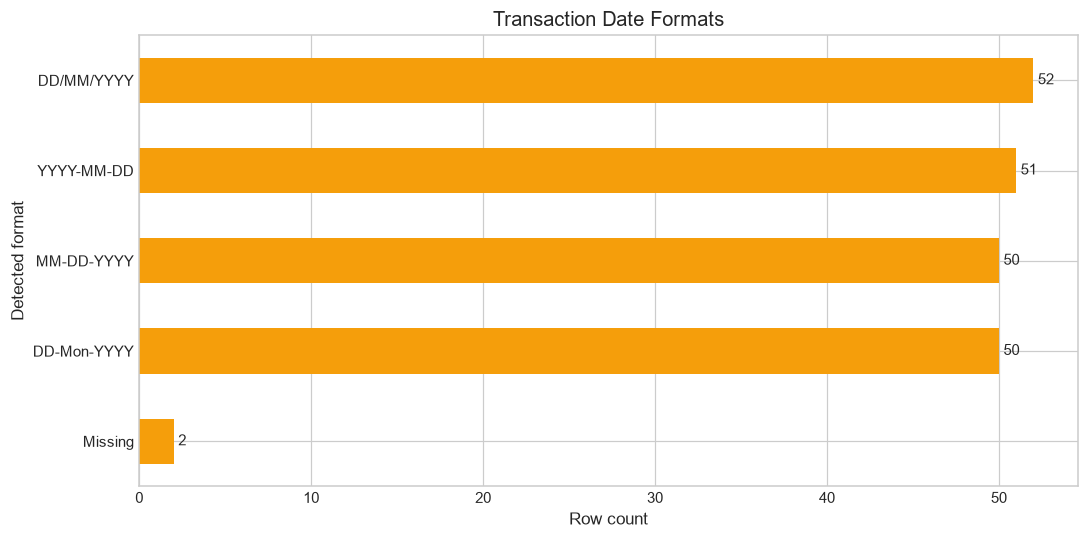

In [15]:
DATE_RULES = [
    (r"^\d{4}-\d{2}-\d{2}$", "YYYY-MM-DD", "%Y-%m-%d"),
    (r"^\d{2}/\d{2}/\d{4}$", "DD/MM/YYYY", "%d/%m/%Y"),
    (r"^\d{2}-\d{2}-\d{4}$", "MM-DD-YYYY", "%m-%d-%Y"),
    (r"^\d{2}-[A-Za-z]{3}-\d{4}$", "DD-Mon-YYYY", "%d-%b-%Y"),
]

def identify_date_format(value):
    if pd.isna(value):
        return "Missing"
    text = str(value).strip()
    for pattern, label, _ in DATE_RULES:
        if re.fullmatch(pattern, text):
            return label
    return "Other"

date_format = df["transaction_date"].map(identify_date_format)
date_format_counts = date_format.value_counts()
display(date_format_counts.rename("row_count").to_frame())

ax = date_format_counts.sort_values().plot(kind="barh", color=SECONDARY_COLOR)
ax.set_title("Transaction Date Formats")
ax.set_xlabel("Row count")
ax.set_ylabel("Detected format")
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
plt.show()

In [16]:
parsed_transaction_date = pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns]")

for pattern, _, date_format_string in DATE_RULES:
    mask = df["transaction_date"].astype("string").str.fullmatch(pattern, na=False)
    parsed_transaction_date.loc[mask] = pd.to_datetime(
        df.loc[mask, "transaction_date"],
        format=date_format_string,
        errors="coerce",
    )

print(f"Parsed dates: {parsed_transaction_date.notna().sum():,}")
print(f"Unparsed or missing dates: {parsed_transaction_date.isna().sum():,}")
print(f"Earliest parsed date: {parsed_transaction_date.min():%Y-%m-%d}")
print(f"Latest parsed date: {parsed_transaction_date.max():%Y-%m-%d}")

Parsed dates: 203
Unparsed or missing dates: 2
Earliest parsed date: 2025-01-01
Latest parsed date: 2025-07-20


## 10. Summarize numeric columns

The table adds median, missing count, interquartile range, and skewness to the standard descriptive statistics.

In [17]:
numeric_summary = df[numeric_columns].describe().T
numeric_summary["median"] = df[numeric_columns].median()
numeric_summary["missing"] = df[numeric_columns].isna().sum()
numeric_summary["iqr"] = numeric_summary["75%"] - numeric_summary["25%"]
numeric_summary["skew"] = df[numeric_columns].skew()

display(
    numeric_summary[[
        "count", "missing", "mean", "median", "std",
        "min", "25%", "75%", "max", "iqr", "skew"
    ]]
)

,count,missing,mean,median,std,min,25%,75%,max,iqr,skew
symboling,205.000,0,0.839,1.000,1.248,-2.000,0.000,2.000,3.000,2.000,0.202
normalized-losses,205.000,0,122.059,122.000,31.748,65.000,101.000,137.000,256.000,36.000,0.846
wheel-base,205.000,0,98.785,97.000,6.019,86.600,94.500,102.400,120.900,7.900,1.038
length,205.000,0,0.837,0.832,0.059,0.678,0.802,0.882,1.000,0.080,0.143
width,205.000,0,0.915,0.910,0.029,0.837,0.890,0.924,1.000,0.033,0.874
height,205.000,0,53.763,54.100,2.439,47.800,52.000,55.500,59.800,3.500,0.025
curb-weight,205.000,0,"2,554.576","2,420.000",515.017,"1,488.000","2,169.000","2,926.000","4,066.000",757.000,0.705
engine-size,205.000,0,126.980,120.000,41.398,61.000,98.000,141.000,326.000,43.000,1.961
bore,205.000,0,3.329,3.310,0.267,2.540,3.150,3.580,3.940,0.430,-0.026
stroke,201.000,4,3.258,3.290,0.316,2.070,3.110,3.410,4.170,0.300,-0.710


## 11. Visualize distributions

### 11.1 Numeric histograms

Each histogram shows the shape, center, spread, and possible skew of one numeric column.

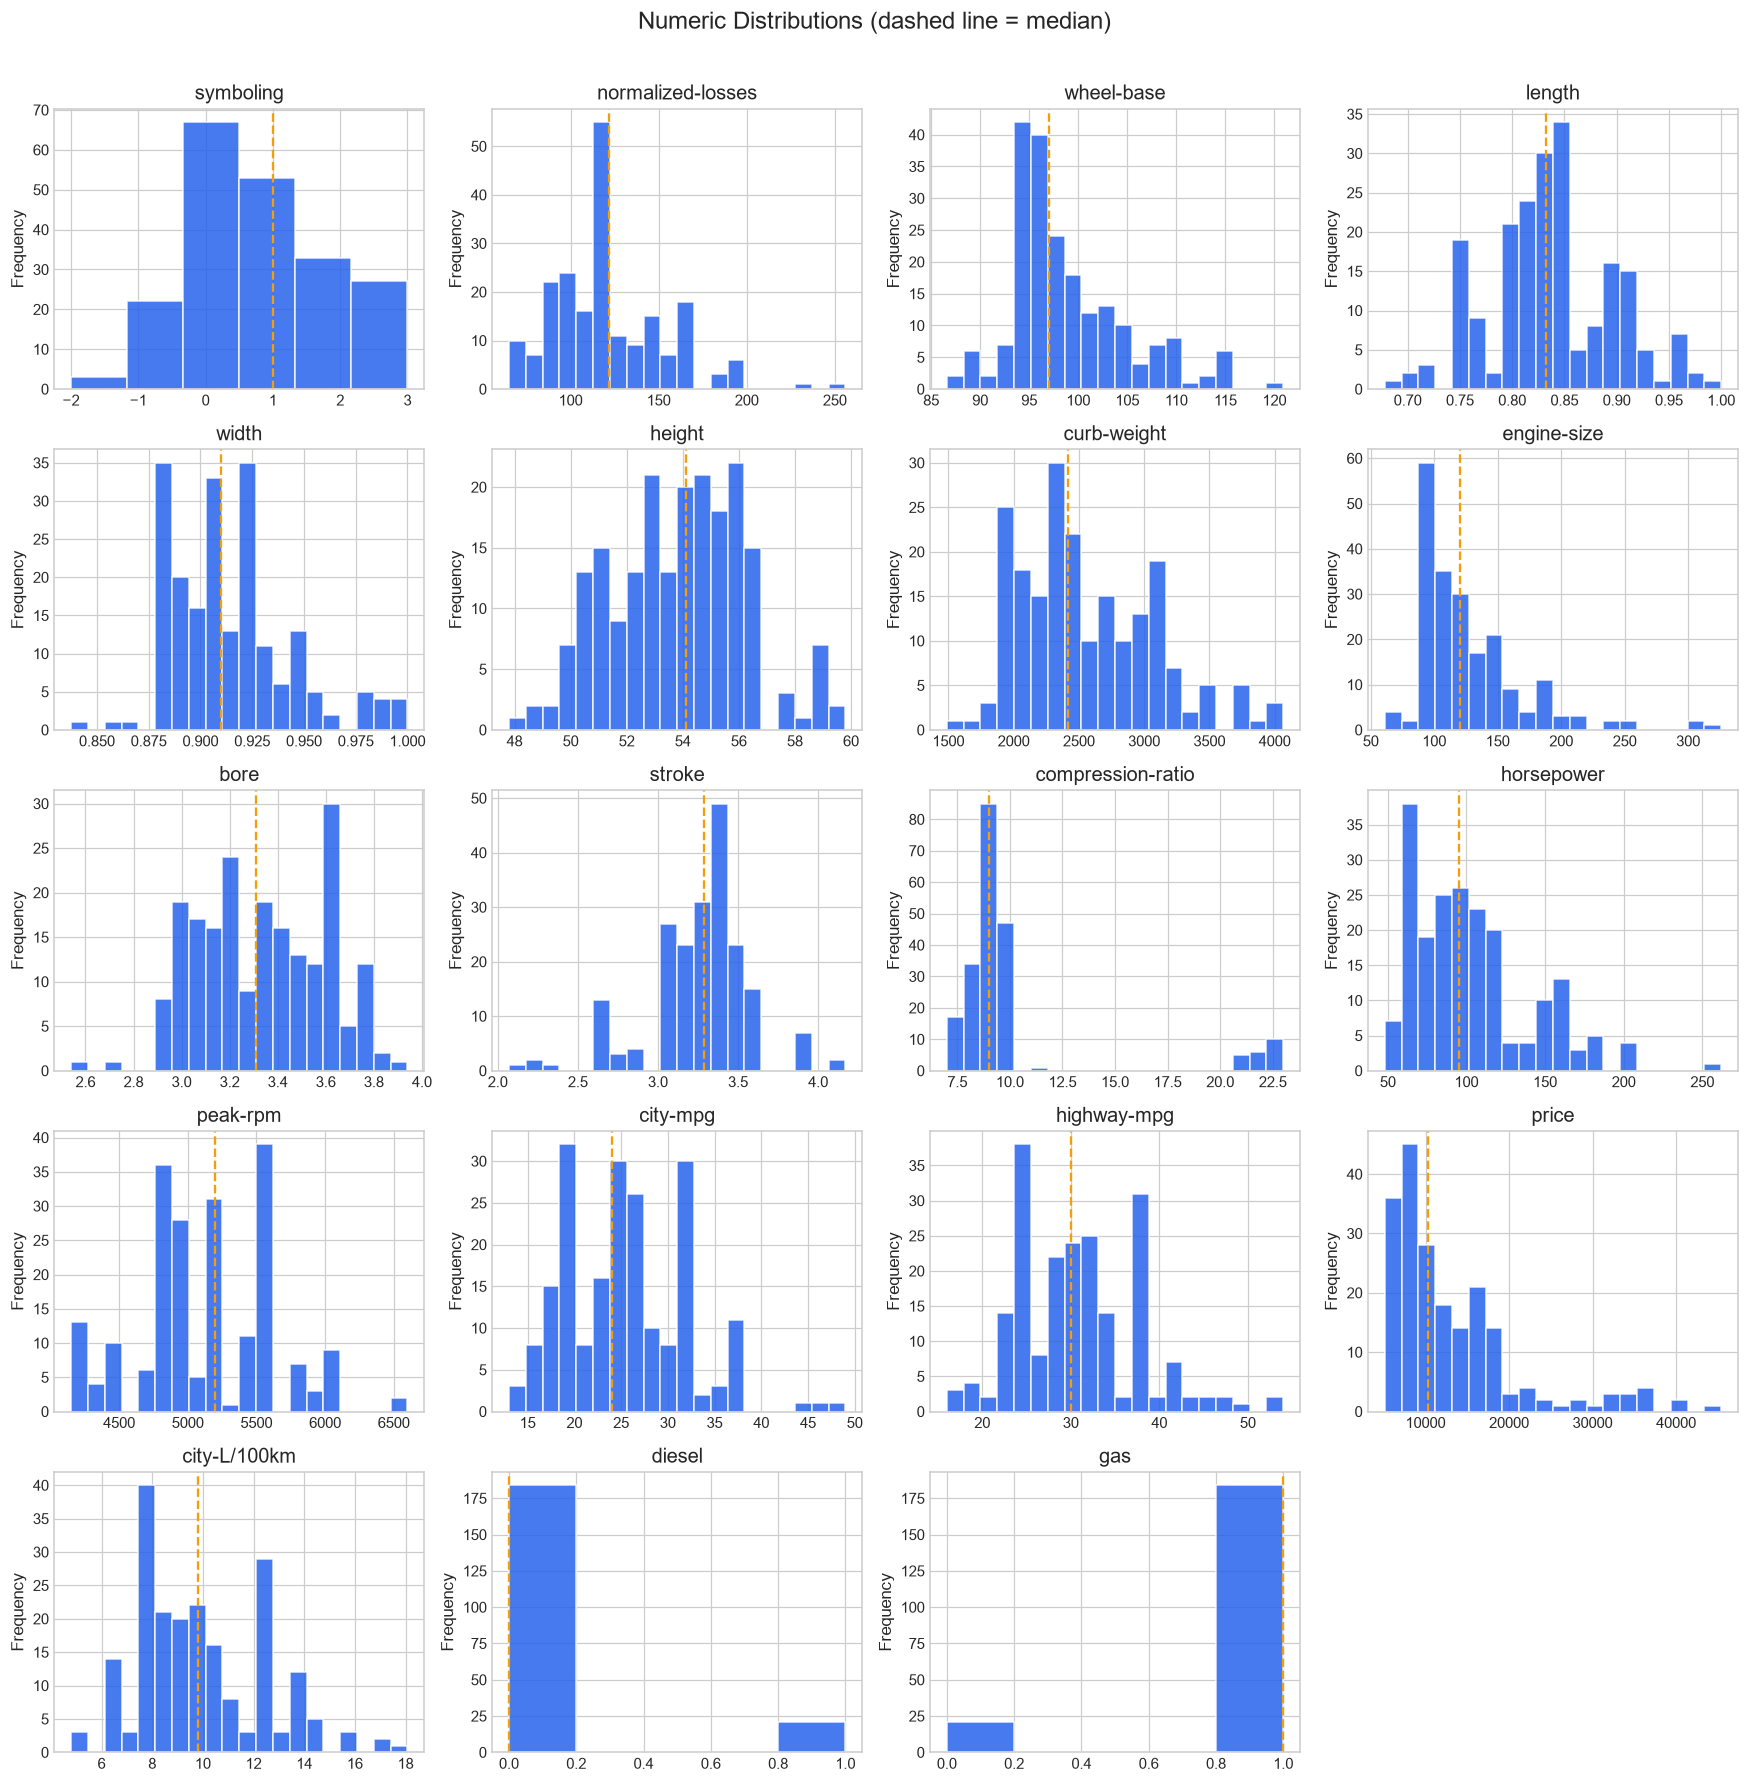

In [18]:
n_columns = 4
n_rows = int(np.ceil(len(numeric_columns) / n_columns))
fig, axes = plt.subplots(n_rows, n_columns, figsize=(16, 3.2 * n_rows))
axes = np.asarray(axes).reshape(-1)

for ax, column in zip(axes, numeric_columns):
    values = df[column].dropna()
    bins = min(20, max(5, values.nunique()))
    ax.hist(values, bins=bins, color=PRIMARY_COLOR, edgecolor="white", alpha=0.85)
    ax.axvline(values.median(), color=SECONDARY_COLOR, linestyle="--", linewidth=1.5)
    ax.set_title(column)
    ax.set_ylabel("Frequency")

for ax in axes[len(numeric_columns):]:
    ax.set_visible(False)

fig.suptitle("Numeric Distributions (dashed line = median)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 11.2 Numeric box plots

Small, separate box plots avoid mixing columns with incompatible measurement scales. Points beyond the whiskers are candidates for investigation, not automatic errors.

C:\Users\rbby-work\AppData\Local\Temp\ipykernel_8544\2765270187.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
C:\Users\rbby-work\AppData\Local\Temp\ipykernel_8544\2765270187.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
C:\Users\rbby-work\AppData\Local\Temp\ipykernel_8544\2765270187.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
C:\Users\rbby-work\AppData\Local\Temp\ipykernel_8544\2765270187.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
C:\Users\rbby-work\AppData\Local\Tem

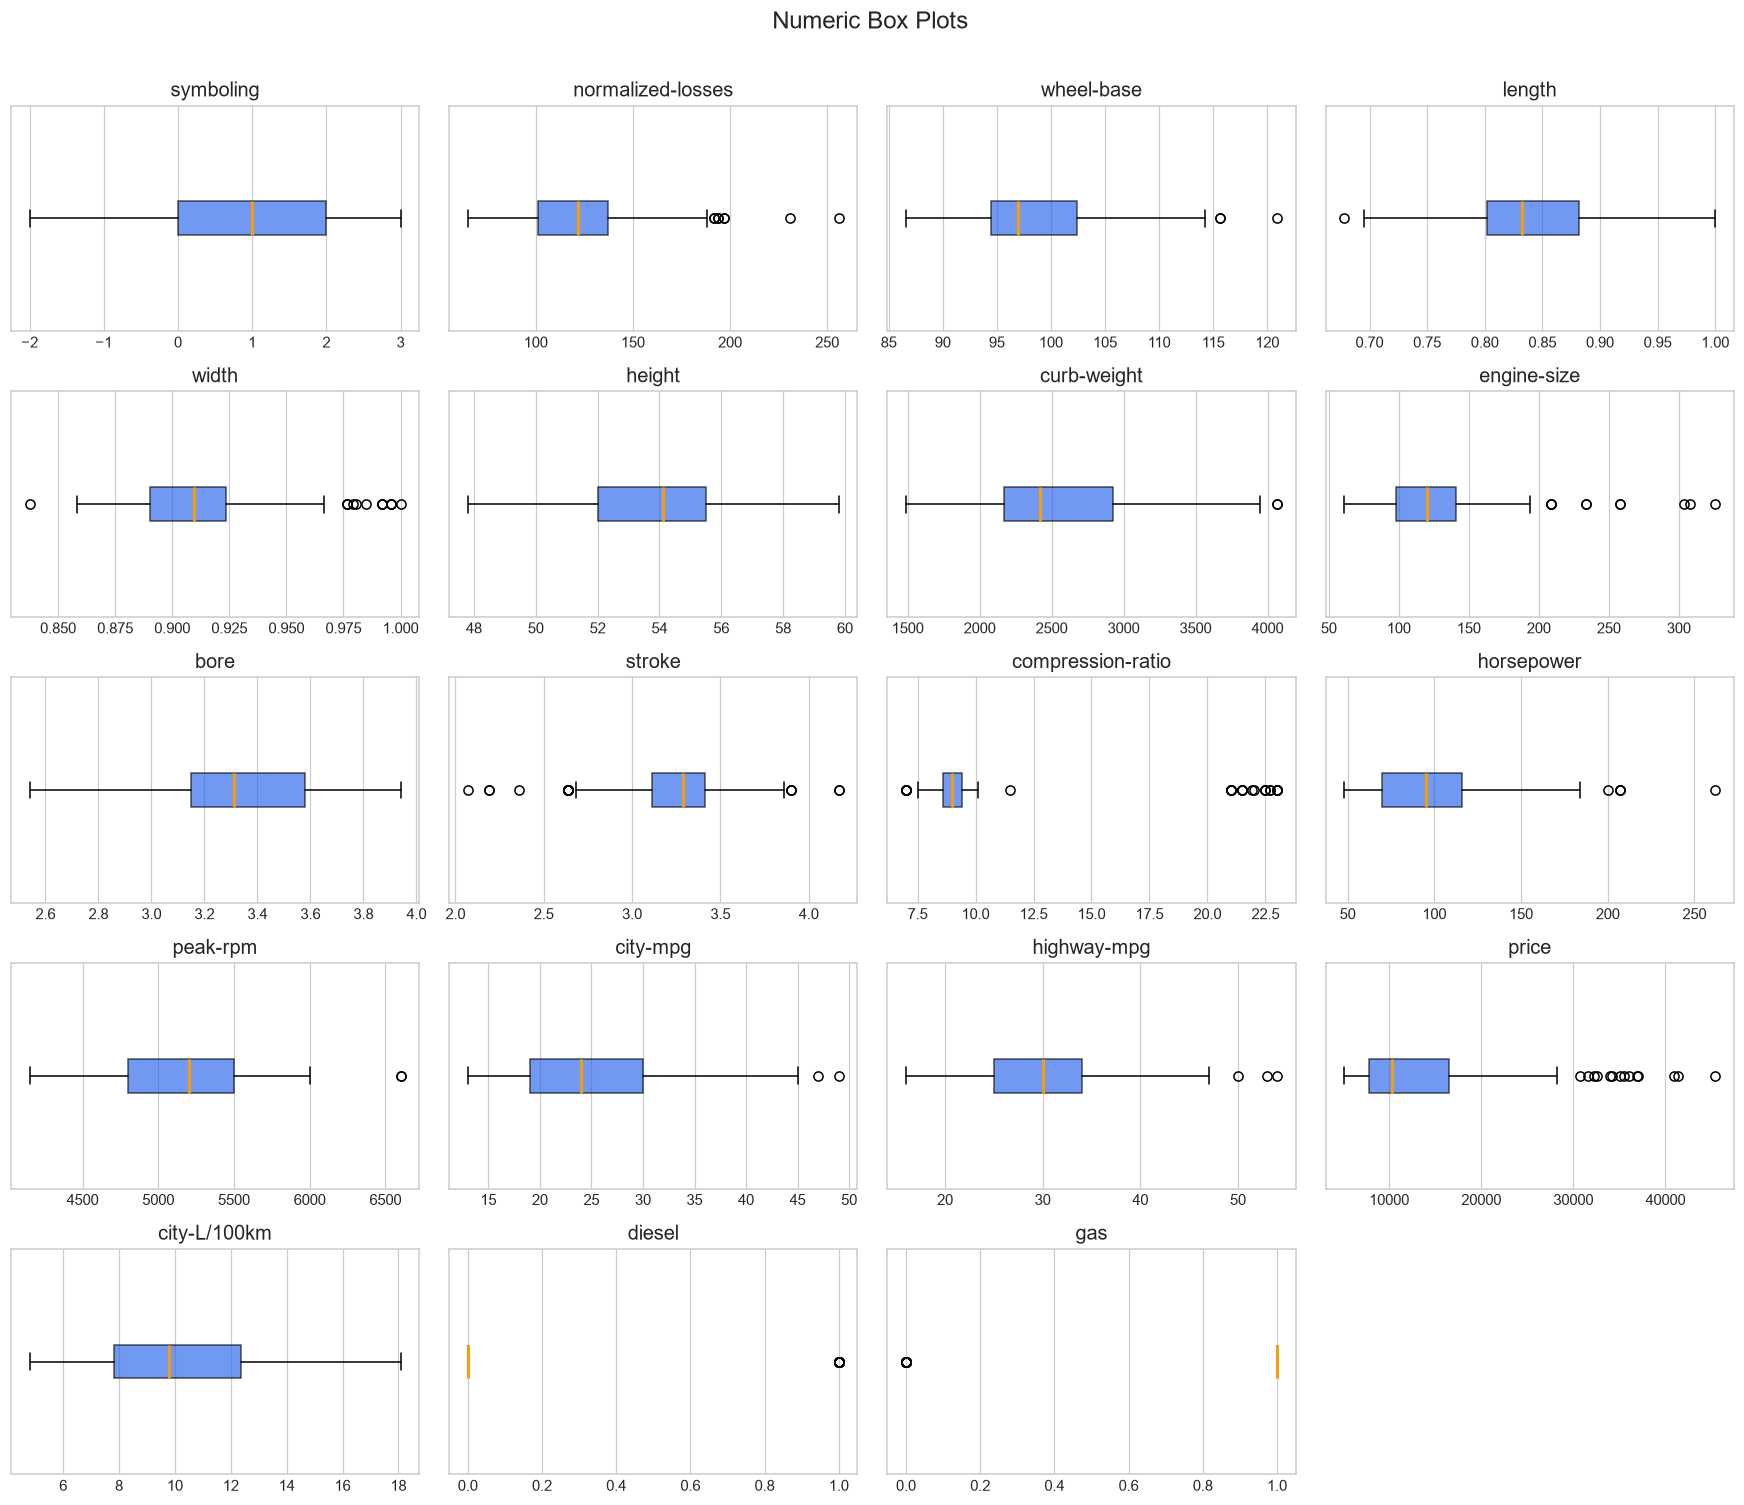

In [19]:
n_columns = 4
n_rows = int(np.ceil(len(numeric_columns) / n_columns))
fig, axes = plt.subplots(n_rows, n_columns, figsize=(16, 2.7 * n_rows))
axes = np.asarray(axes).reshape(-1)

for ax, column in zip(axes, numeric_columns):
    ax.boxplot(
        df[column].dropna(),
        vert=False,
        patch_artist=True,
        boxprops={"facecolor": PRIMARY_COLOR, "alpha": 0.65},
        medianprops={"color": SECONDARY_COLOR, "linewidth": 2},
    )
    ax.set_title(column)
    ax.set_yticks([])

for ax in axes[len(numeric_columns):]:
    ax.set_visible(False)

fig.suptitle("Numeric Box Plots", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 11.3 Categorical distributions

Plot the most frequent values for each categorical column except the transaction date, which was analyzed separately. Missing values are shown as `<Missing>`.

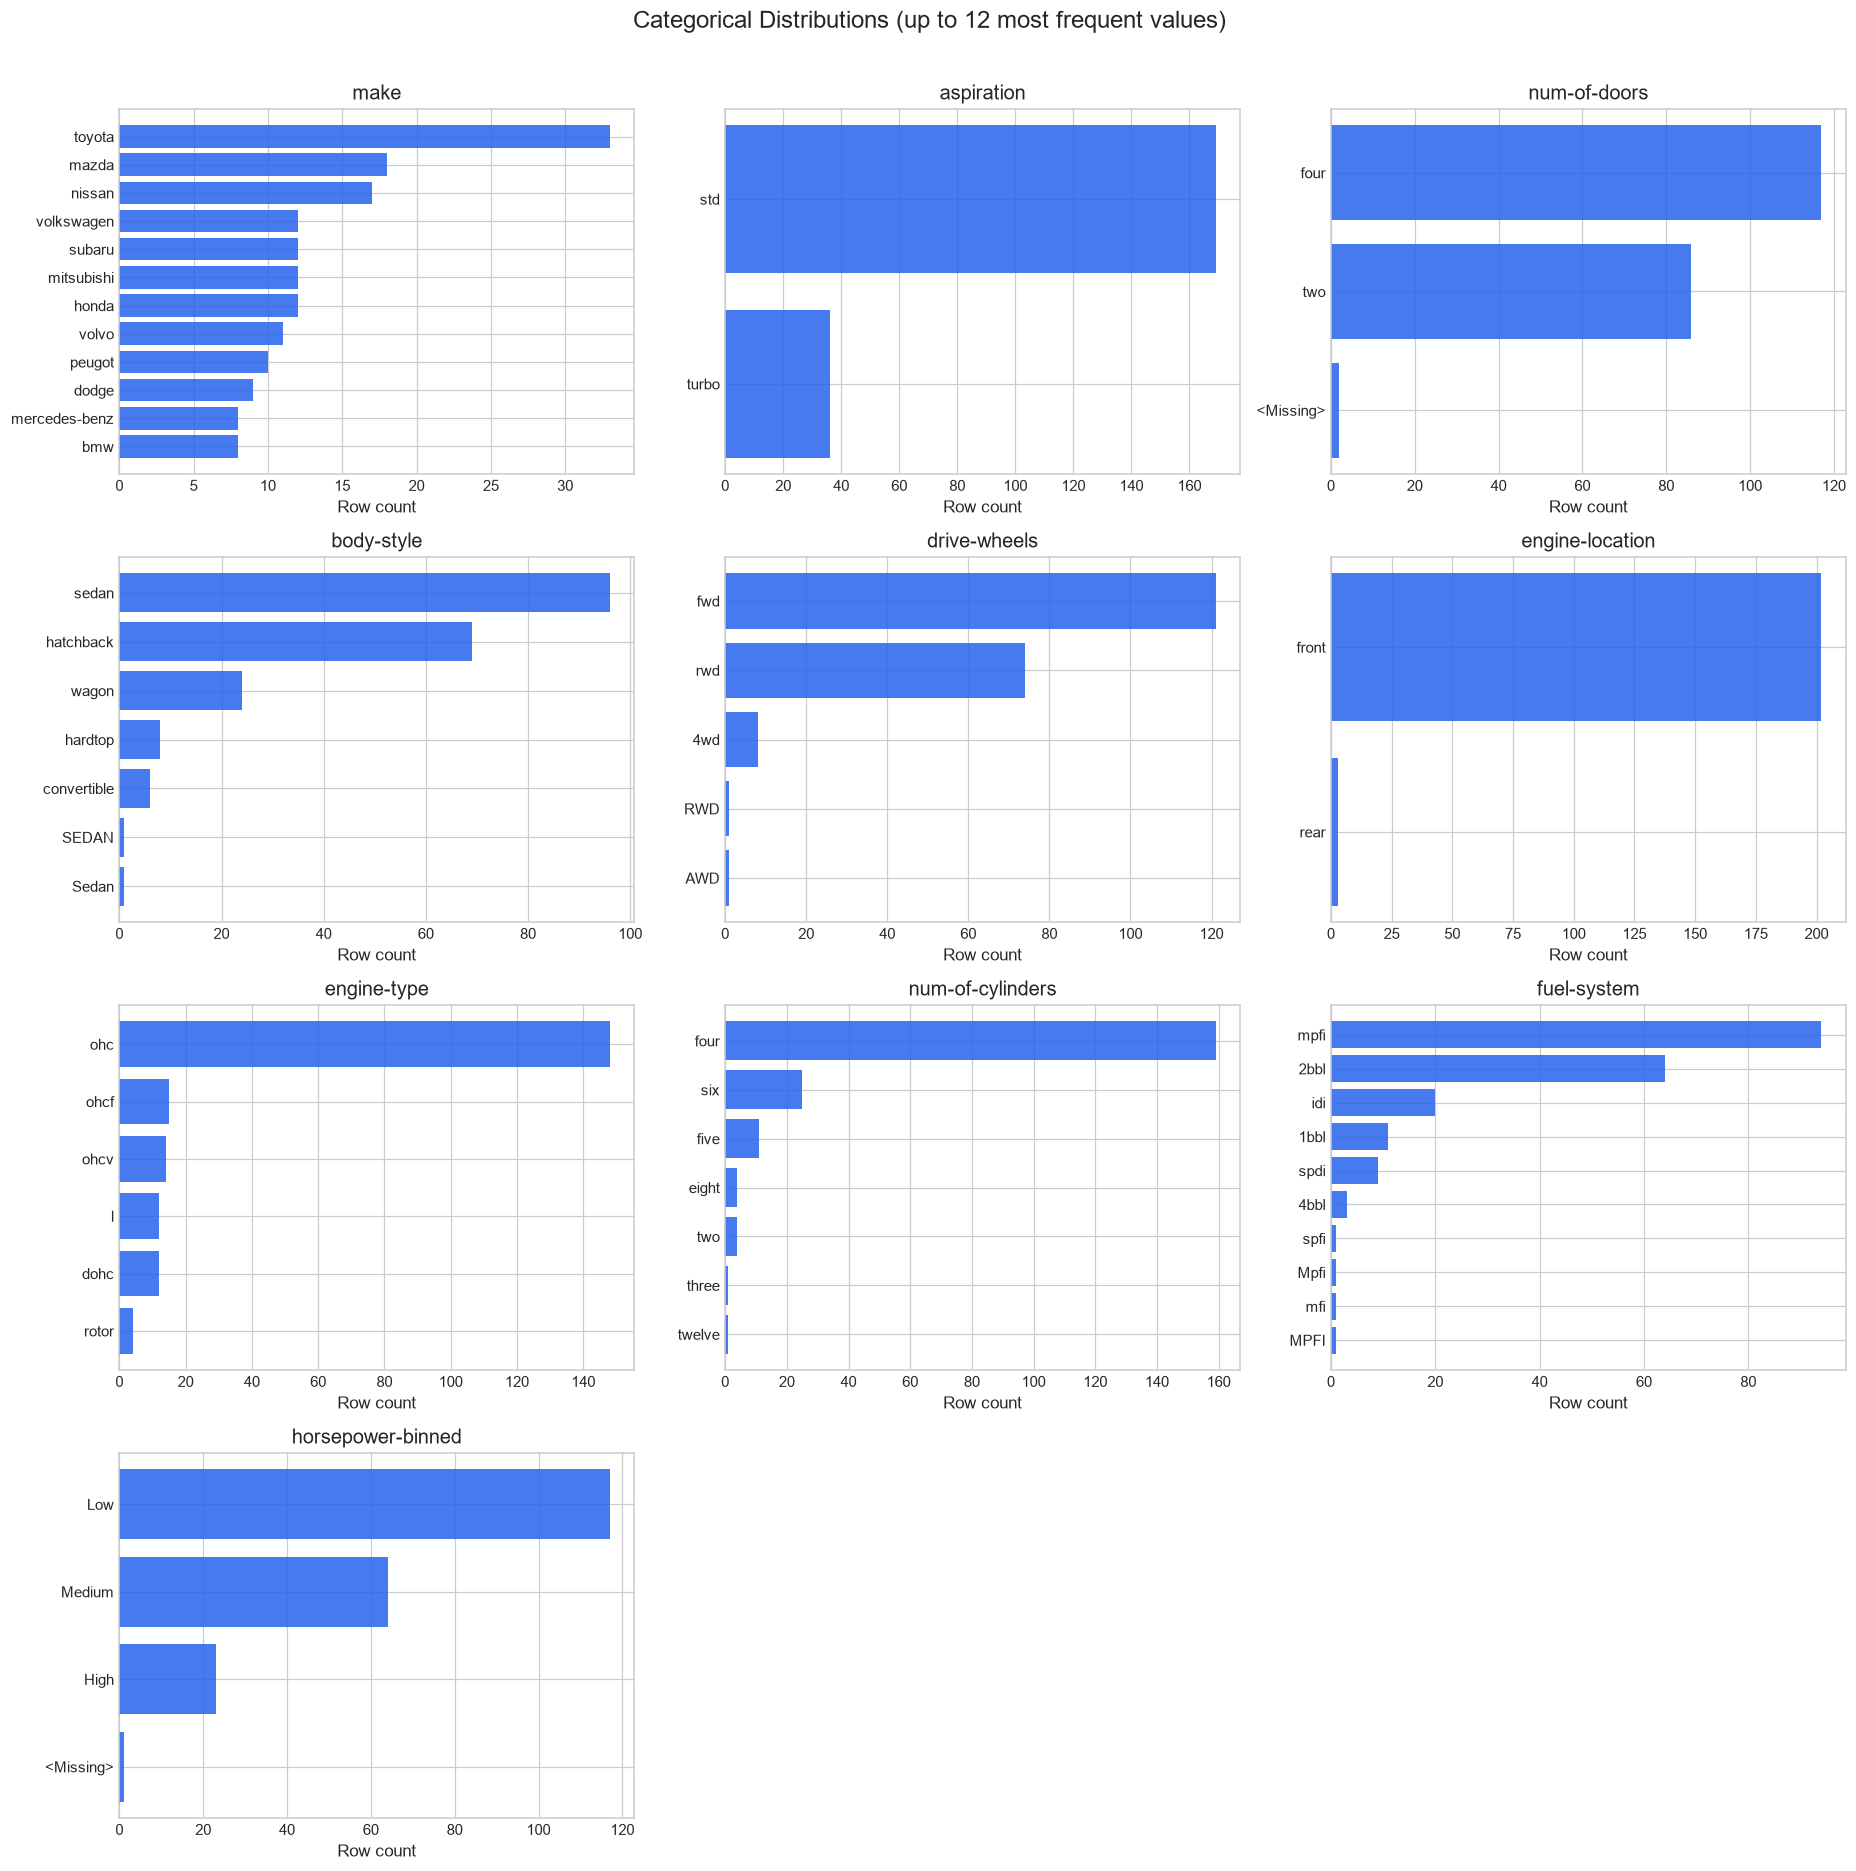

In [20]:
plot_categorical_columns = [
    column for column in categorical_columns if column != "transaction_date"
]
n_columns = 3
n_rows = int(np.ceil(len(plot_categorical_columns) / n_columns))
fig, axes = plt.subplots(n_rows, n_columns, figsize=(17, 4.2 * n_rows))
axes = np.asarray(axes).reshape(-1)

for ax, column in zip(axes, plot_categorical_columns):
    counts = (
        df[column]
        .fillna("<Missing>")
        .astype(str)
        .value_counts()
        .head(12)
        .sort_values()
    )
    ax.barh(counts.index, counts.values, color=PRIMARY_COLOR, alpha=0.85)
    ax.set_title(column)
    ax.set_xlabel("Row count")

for ax in axes[len(plot_categorical_columns):]:
    ax.set_visible(False)

fig.suptitle("Categorical Distributions (up to 12 most frequent values)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 12. Visualize relationships

### 12.1 Numeric correlation heatmap

Correlation ranges from -1 to +1. Strong correlation does not prove that one variable causes another.

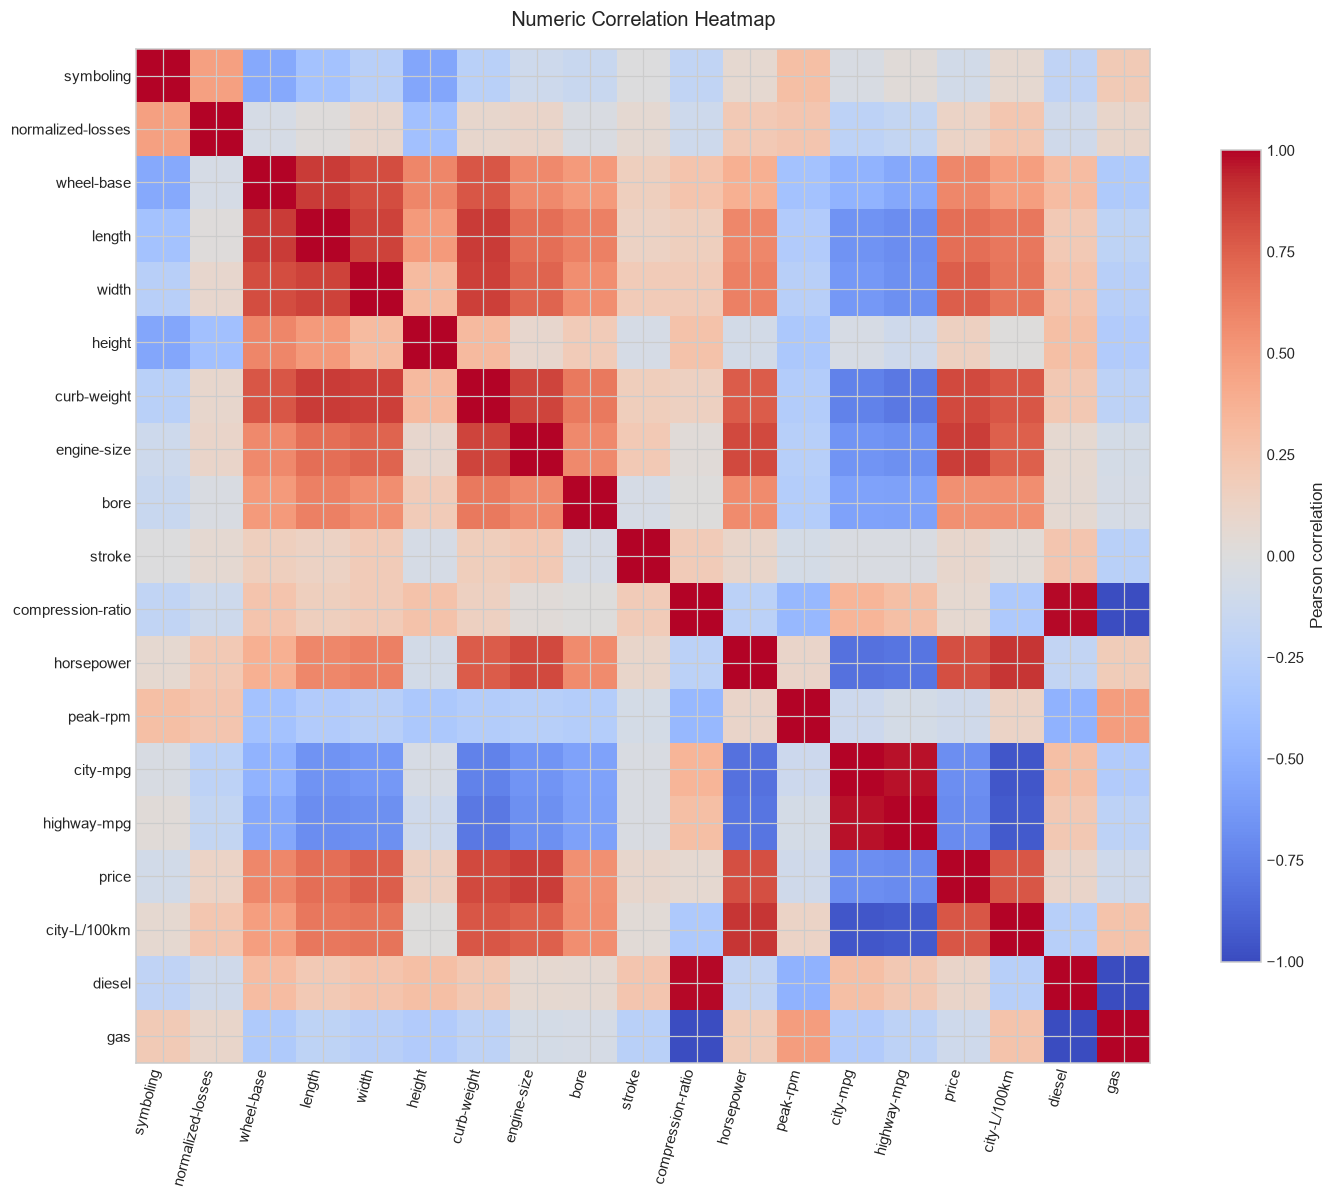

In [21]:
correlation = df[numeric_columns].corr()
fig, ax = plt.subplots(figsize=(14, 11))
image = ax.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.columns)))
ax.set_xticklabels(correlation.columns, rotation=75, ha="right")
ax.set_yticklabels(correlation.columns)
ax.set_title("Numeric Correlation Heatmap", pad=15)
fig.colorbar(image, ax=ax, label="Pearson correlation", shrink=0.8)
plt.tight_layout()
plt.show()

### 12.2 Selected relationships with price

Engine size and horsepower are plausible explanatory variables for automobile price, so inspect them directly.

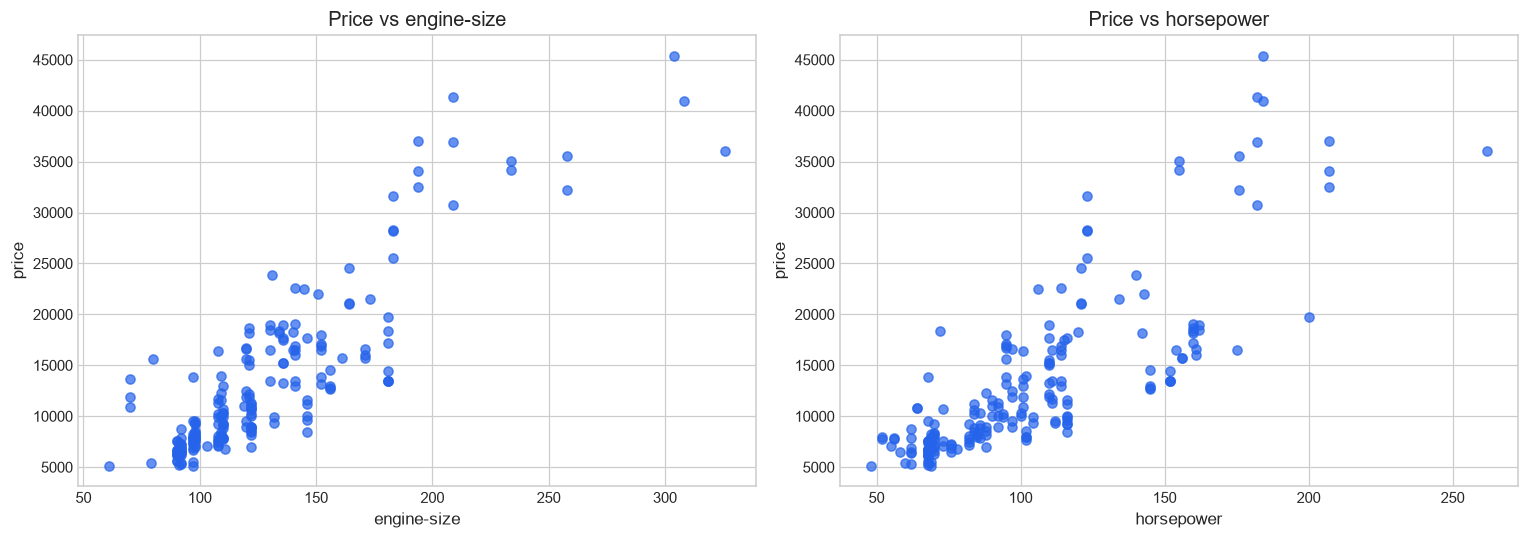

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, x_column in zip(axes, ["engine-size", "horsepower"]):
    valid = df[[x_column, "price"]].dropna()
    ax.scatter(valid[x_column], valid["price"], color=PRIMARY_COLOR, alpha=0.7)
    ax.set_title(f"Price vs {x_column}")
    ax.set_xlabel(x_column)
    ax.set_ylabel("price")

plt.tight_layout()
plt.show()

### 12.3 Price by body style

Use a temporary normalized body-style series so capitalization variants do not split the same category in this diagnostic chart.

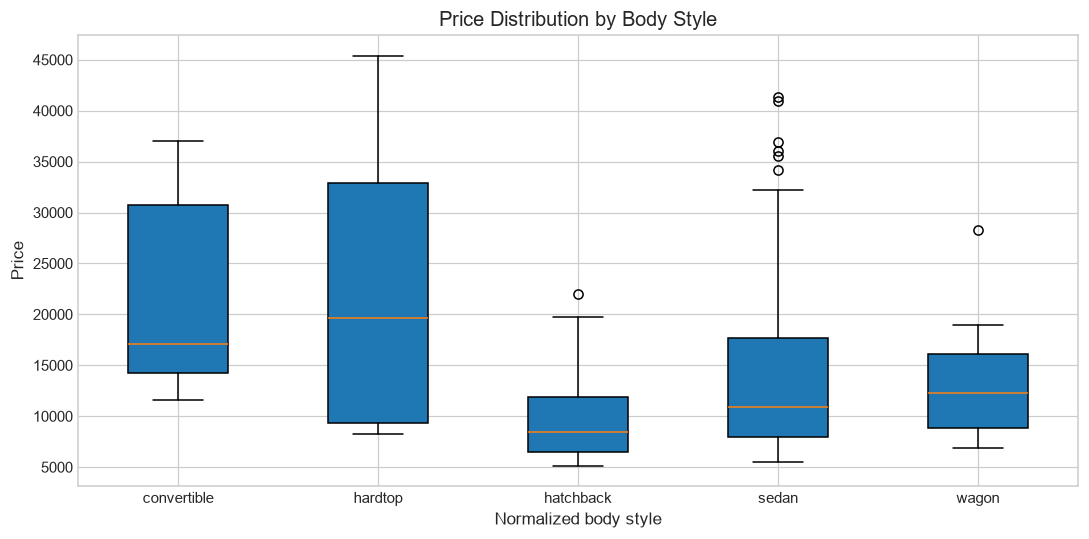

In [23]:
price_by_body_style = pd.DataFrame({
    "body_style_normalized": df["body-style"].astype("string").str.strip().str.lower(),
    "price": df["price"],
}).dropna()

body_styles = sorted(price_by_body_style["body_style_normalized"].unique())
price_groups = [
    price_by_body_style.loc[
        price_by_body_style["body_style_normalized"] == body_style, "price"
    ]
    for body_style in body_styles
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(price_groups, patch_artist=True)
ax.set_xticks(range(1, len(body_styles) + 1), body_styles)
ax.set_title("Price Distribution by Body Style")
ax.set_xlabel("Normalized body style")
ax.set_ylabel("Price")
plt.tight_layout()
plt.show()

## 13. Consolidated inspection summary

Generate a compact set of facts that can be copied into the project README before deciding on cleaning rules.

In [24]:
summary = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "numeric_columns": len(numeric_columns),
    "categorical_columns": len(categorical_columns),
    "missing_cells": int(df.isna().sum().sum()),
    "columns_with_missing_values": int(df.isna().any().sum()),
    "duplicate_copies": duplicate_copy_count,
    "unique_rows": len(df.drop_duplicates()),
    "detected_date_formats": int(date_format[date_format != "Missing"].nunique()),
    "unparsed_or_missing_dates": int(parsed_transaction_date.isna().sum()),
})

display(summary.rename("value").to_frame())

,value
rows,205
columns,30
numeric_columns,19
categorical_columns,11
missing_cells,17
columns_with_missing_values,7
duplicate_copies,4
unique_rows,201
detected_date_formats,4
unparsed_or_missing_dates,2


In [25]:
assert df.equals(df_raw), "The inspection dataframe was unexpectedly modified."
print("Verification passed: the raw dataframe was not changed during this notebook.")

Verification passed: the raw dataframe was not changed during this notebook.
